# Clutter Removal Experiment

Use this notebook to analyze the results of a clutter removal experiment.

In [1]:
import os
os.chdir('..')

In [2]:
from pathlib import Path

from vgn.experiments import clutter_removal

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


pybullet build time: Jan 29 2025 23:19:57


Path to the log directory of the experiment.

In [3]:
logdir = Path("data/experiments/26-03-31-10-55-57")

In [4]:
data = clutter_removal.Data(logdir)

First, we compute the following metrics for the experiment:

* **Success rate**: the ratio of successful grasp executions,
* **Percent cleared**: the percentage of objects removed during each round,
* **Planning time**: the time between receiving a voxel grid/point cloud and returning a list of grasp candidates.

In [5]:
print("Num grasps:        ", data.num_grasps())
print("Success rate:      ", data.success_rate())
print("Percent cleared:   ", data.percent_cleared())
print("Avg planning time: ", data.avg_planning_time())

Num grasps:         209
Success rate:       81.3397129186603
Percent cleared:    85.0
Avg planning time:  0.08622917832370006


Next, we visualize the failure cases. Make sure to have a ROS core running and open `config/sim.rviz` in RViz.

In [6]:
import rospy
from vgn import vis

rospy.init_node("vgn_vis", anonymous=True)

<MagicMock name='mock.init_node()' id='134373595705600'>

In [7]:
failures = data.grasps[data.grasps["label"] == 0].index.tolist()
iterator = iter(failures)

In [8]:
i = next(iterator)
points, grasp, score, label = data.read_grasp(i)

vis.clear()
vis.draw_workspace(0.3)
vis.draw_points(points)
vis.draw_grasp(grasp, label, 0.05)

Metric                          Pile     Packed
Num Grasps                       209        166
Success Rate (%)                81.3       95.8
Percent Cleared (%)             85.0       97.6
Avg Planning Time (ms)          86.2       81.4


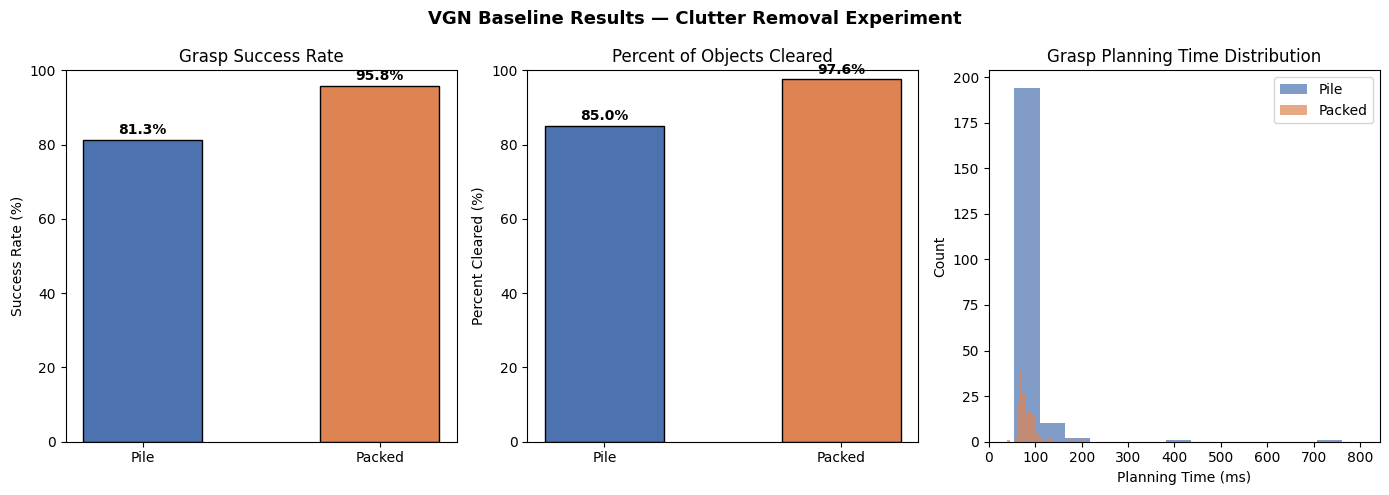

Saved to data/experiments/vgn_baseline_results.png


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
pile = pd.read_csv("data/experiments/26-03-31-10-55-57/grasps.csv")
packed = pd.read_csv("data/experiments/26-03-31-11-19-41/grasps.csv")
pile_rounds = pd.read_csv("data/experiments/26-03-31-10-55-57/rounds.csv")
packed_rounds = pd.read_csv("data/experiments/26-03-31-11-19-41/rounds.csv")

# Compute percent cleared per round (successful grasps / object count)
def compute_percent_cleared(grasps, rounds):
    successful = grasps[grasps["label"] == 1].groupby("round_id").size().reset_index(name="successes")
    merged = rounds.merge(successful, on="round_id", how="left").fillna(0)
    merged["percent_cleared"] = (merged["successes"] / merged["object_count"]).clip(0, 1) * 100
    return merged["percent_cleared"].mean()

pile_pc   = compute_percent_cleared(pile, pile_rounds)
packed_pc = compute_percent_cleared(packed, packed_rounds)

# Metrics summary
print(f"{'':=<50}")
print(f"{'Metric':<25} {'Pile':>10} {'Packed':>10}")
print(f"{'':=<50}")
print(f"{'Num Grasps':<25} {len(pile):>10} {len(packed):>10}")
print(f"{'Success Rate (%)':<25} {pile['label'].mean()*100:>10.1f} {packed['label'].mean()*100:>10.1f}")
print(f"{'Percent Cleared (%)':<25} {pile_pc:>10.1f} {packed_pc:>10.1f}")
print(f"{'Avg Planning Time (ms)':<25} {pile['planning_time'].mean()*1000:>10.1f} {packed['planning_time'].mean()*1000:>10.1f}")
print(f"{'':=<50}")

# ── Plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("VGN Baseline Results — Clutter Removal Experiment", fontsize=13, fontweight="bold")
colors = ["#4C72B0", "#DD8452"]

# Plot 1: Success Rate
sr = [pile["label"].mean()*100, packed["label"].mean()*100]
axes[0].bar(["Pile", "Packed"], sr, color=colors, width=0.5, edgecolor="black")
axes[0].set_title("Grasp Success Rate")
axes[0].set_ylabel("Success Rate (%)")
axes[0].set_ylim(0, 100)
for i, v in enumerate(sr):
    axes[0].text(i, v + 1.5, f"{v:.1f}%", ha="center", fontweight="bold")

# Plot 2: Percent Cleared
pc = [pile_pc, packed_pc]
axes[1].bar(["Pile", "Packed"], pc, color=colors, width=0.5, edgecolor="black")
axes[1].set_title("Percent of Objects Cleared")
axes[1].set_ylabel("Percent Cleared (%)")
axes[1].set_ylim(0, 100)
for i, v in enumerate(pc):
    axes[1].text(i, v + 1.5, f"{v:.1f}%", ha="center", fontweight="bold")

# Plot 3: Planning Time Distribution
axes[2].hist(pile["planning_time"]*1000,   bins=30, alpha=0.7, label="Pile",   color=colors[0])
axes[2].hist(packed["planning_time"]*1000, bins=30, alpha=0.7, label="Packed", color=colors[1])
axes[2].set_xlim(left=0)   
axes[2].set_title("Grasp Planning Time Distribution")
axes[2].set_xlabel("Planning Time (ms)")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.savefig("data/experiments/vgn_baseline_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to data/experiments/vgn_baseline_results.png")

In [10]:
import pandas as pd
pile_rounds = pd.read_csv("data/experiments/26-03-31-10-55-57/rounds.csv")
print(pile_rounds.columns.tolist())
print(pile_rounds.head(3))

['round_id', 'object_count']
   round_id  object_count
0         0             5
1         1             5
2         2             5



───────────────────────────────────────────────────────
  PILE
───────────────────────────────────────────────────────
  Run      Success Rate    % Cleared   Plan Time (ms)
  Run 1            81.3%        85.0%           86.2
  Run 2            79.0%        79.0%           73.1
  Run 3            83.3%        82.5%           70.1
  ───────────────────────────────────────────────────
  Mean            81.2%        82.2%           76.5
  Std             1.77         2.46            7.01

───────────────────────────────────────────────────────
  PACKED
───────────────────────────────────────────────────────
  Run      Success Rate    % Cleared   Plan Time (ms)
  Run 1            95.8%        97.6%           81.4
  Run 2            91.3%        97.0%           68.7
  Run 3            93.9%        95.8%           69.9
  ───────────────────────────────────────────────────
  Mean            93.7%        96.8%           73.3
  Std             1.83         0.78            5.70


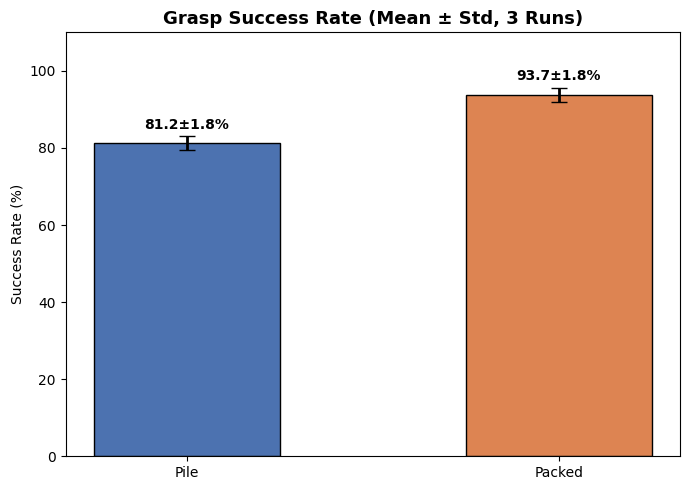

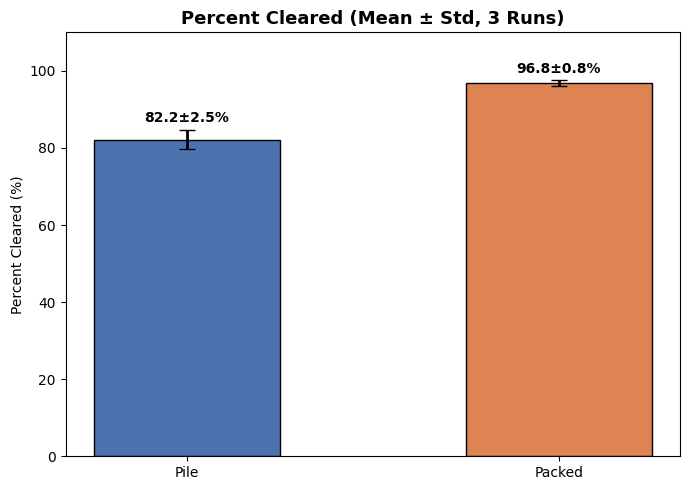

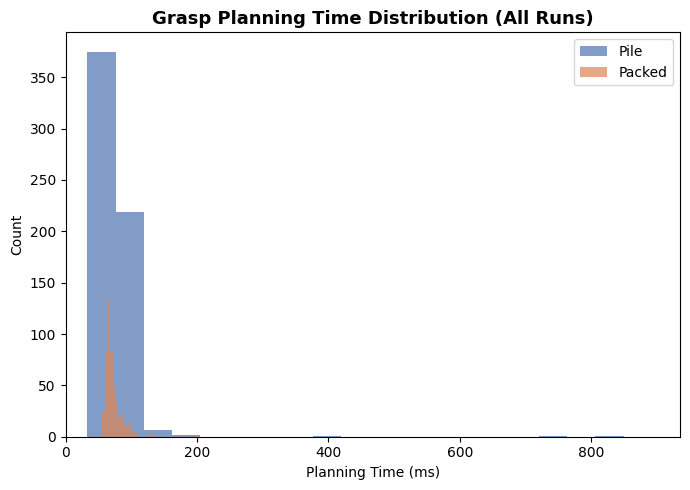

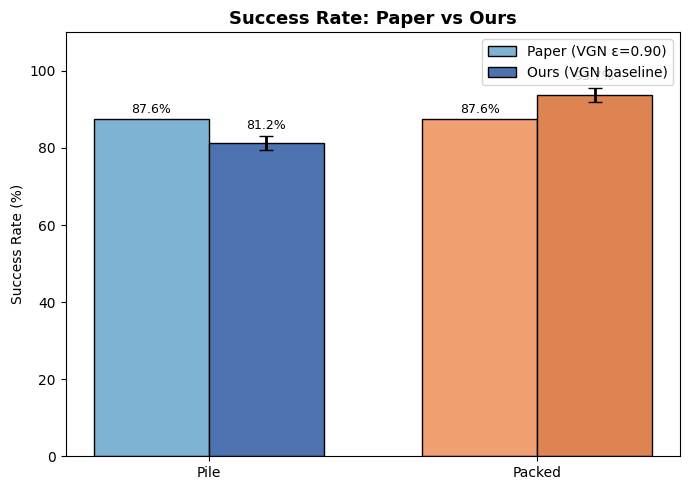

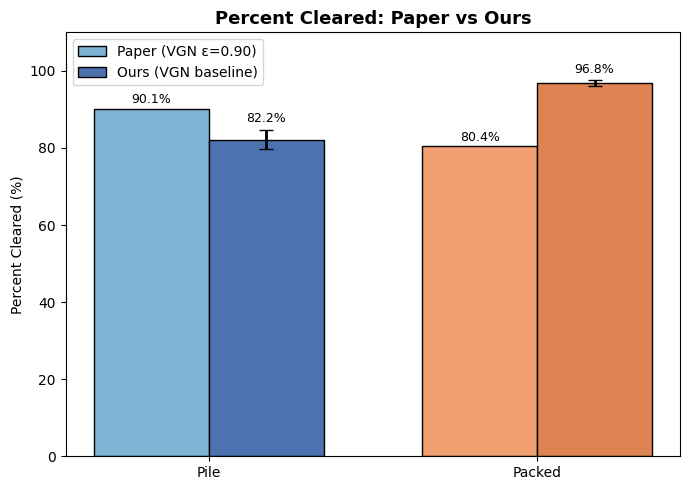

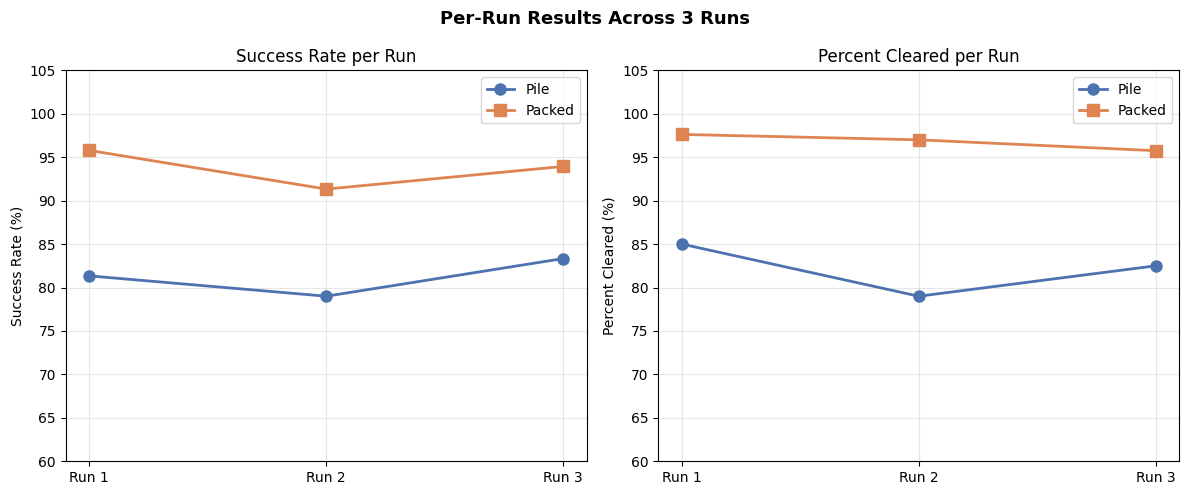


✅ All 6 graphs saved to data/experiments/

📋 FILL THESE INTO YOUR LATEX TABLE:
   Pile   SR:  81.2 ± 1.8
   Pile   PC:  82.2 ± 2.5
   Packed SR:  93.7 ± 1.8
   Packed PC:  96.8 ± 0.8


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Load all runs ─────────────────────────────────────────────────
pile_dirs = [
    "data/experiments/26-03-31-10-55-57",
    "data/experiments/26-03-31-18-56-45",
    "data/experiments/26-03-31-19-01-00",
]
packed_dirs = [
    "data/experiments/26-03-31-11-19-41",
    "data/experiments/26-03-31-19-06-09",
    "data/experiments/26-03-31-19-11-34",
]

def load_run(d):
    g = pd.read_csv(f"{d}/grasps.csv")
    r = pd.read_csv(f"{d}/rounds.csv")
    return g, r

def compute_metrics(d):
    g, r = load_run(d)
    successful = g[g["label"]==1].groupby("round_id").size().reset_index(name="successes")
    merged = r.merge(successful, on="round_id", how="left").fillna(0)
    merged["pct_cleared"] = (merged["successes"] / merged["object_count"]).clip(0,1) * 100
    return {
        "n_grasps":    len(g),
        "success_rate": g["label"].mean() * 100,
        "pct_cleared":  merged["pct_cleared"].mean(),
        "plan_time_ms": g["planning_time"].mean() * 1000,
    }

pile_metrics   = [compute_metrics(d) for d in pile_dirs]
packed_metrics = [compute_metrics(d) for d in packed_dirs]

def summarize(metrics, label):
    sr  = [m["success_rate"] for m in metrics]
    pc  = [m["pct_cleared"]  for m in metrics]
    pt  = [m["plan_time_ms"] for m in metrics]
    print(f"\n{'─'*55}")
    print(f"  {label}")
    print(f"{'─'*55}")
    print(f"  {'Run':<6} {'Success Rate':>14} {'% Cleared':>12} {'Plan Time (ms)':>16}")
    for i,(m,s,p,t) in enumerate(zip(metrics,sr,pc,pt)):
        print(f"  Run {i+1:<3} {s:>13.1f}% {p:>11.1f}% {t:>14.1f}")
    print(f"  {'─'*51}")
    print(f"  {'Mean':<6} {np.mean(sr):>13.1f}% {np.mean(pc):>11.1f}% {np.mean(pt):>14.1f}")
    print(f"  {'Std':<6} {np.std(sr):>13.2f}  {np.std(pc):>11.2f}  {np.std(pt):>14.2f}")
    return np.mean(sr), np.std(sr), np.mean(pc), np.std(pc), np.mean(pt), np.std(pt)

pile_sr_m,   pile_sr_s,   pile_pc_m,   pile_pc_s,   pile_pt_m,   pile_pt_s   = summarize(pile_metrics,   "PILE")
packed_sr_m, packed_sr_s, packed_pc_m, packed_pc_s, packed_pt_m, packed_pt_s = summarize(packed_metrics, "PACKED")

# ── Paper values for comparison ───────────────────────────────────
paper_pile_sr,   paper_pile_pc   = 87.6, 90.1
paper_packed_sr, paper_packed_pc = 87.6, 80.4

colors_ours  = ["#4C72B0", "#DD8452"]
colors_paper = ["#7FB3D3", "#F0A070"]
scenes = ["Pile", "Packed"]
x = np.arange(2)
w = 0.35

# ════════════════════════════════════════════════════════════════════
# GRAPH 1 — Success Rate with error bars
# ════════════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(7, 5))
means = [pile_sr_m, packed_sr_m]
stds  = [pile_sr_s, packed_sr_s]
bars  = ax1.bar(x, means, width=0.5, color=colors_ours, edgecolor="black",
                yerr=stds, capsize=6, error_kw={"linewidth":2})
ax1.set_title("Grasp Success Rate (Mean ± Std, 3 Runs)", fontweight="bold", fontsize=13)
ax1.set_ylabel("Success Rate (%)")
ax1.set_xticks(x); ax1.set_xticklabels(scenes)
ax1.set_ylim(0, 110)
for bar, m, s in zip(bars, means, stds):
    ax1.text(bar.get_x()+bar.get_width()/2, m+s+2,
             f"{m:.1f}±{s:.1f}%", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("data/experiments/graph1_success_rate.png", dpi=150, bbox_inches="tight")
plt.show()

# ════════════════════════════════════════════════════════════════════
# GRAPH 2 — Percent Cleared with error bars
# ════════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(7, 5))
means = [pile_pc_m, packed_pc_m]
stds  = [pile_pc_s, packed_pc_s]
bars  = ax2.bar(x, means, width=0.5, color=colors_ours, edgecolor="black",
                yerr=stds, capsize=6, error_kw={"linewidth":2})
ax2.set_title("Percent Cleared (Mean ± Std, 3 Runs)", fontweight="bold", fontsize=13)
ax2.set_ylabel("Percent Cleared (%)")
ax2.set_xticks(x); ax2.set_xticklabels(scenes)
ax2.set_ylim(0, 110)
for bar, m, s in zip(bars, means, stds):
    ax2.text(bar.get_x()+bar.get_width()/2, m+s+2,
             f"{m:.1f}±{s:.1f}%", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("data/experiments/graph2_pct_cleared.png", dpi=150, bbox_inches="tight")
plt.show()

# ════════════════════════════════════════════════════════════════════
# GRAPH 3 — Planning Time Distribution (all runs overlaid)
# ════════════════════════════════════════════════════════════════════
fig3, ax3 = plt.subplots(figsize=(7, 5))
all_pile_pt   = pd.concat([pd.read_csv(f"{d}/grasps.csv")["planning_time"] for d in pile_dirs])
all_packed_pt = pd.concat([pd.read_csv(f"{d}/grasps.csv")["planning_time"] for d in packed_dirs])
ax3.hist(all_pile_pt*1000,   bins=40, alpha=0.7, label="Pile",   color=colors_ours[0])
ax3.hist(all_packed_pt*1000, bins=40, alpha=0.7, label="Packed", color=colors_ours[1])
ax3.set_xlim(left=0)
ax3.set_title("Grasp Planning Time Distribution (All Runs)", fontweight="bold", fontsize=13)
ax3.set_xlabel("Planning Time (ms)")
ax3.set_ylabel("Count")
ax3.legend()
plt.tight_layout()
plt.savefig("data/experiments/graph3_plan_time.png", dpi=150, bbox_inches="tight")
plt.show()

# ════════════════════════════════════════════════════════════════════
# GRAPH 4 — Paper vs Ours: Success Rate
# ════════════════════════════════════════════════════════════════════
fig4, ax4 = plt.subplots(figsize=(7, 5))
b1 = ax4.bar(x-w/2, [paper_pile_sr, paper_packed_sr], w,
             label="Paper (VGN ε=0.90)", color=colors_paper, edgecolor="black")
b2 = ax4.bar(x+w/2, [pile_sr_m, packed_sr_m], w,
             label="Ours (VGN baseline)", color=colors_ours, edgecolor="black",
             yerr=[pile_sr_s, packed_sr_s], capsize=5, error_kw={"linewidth":2})
ax4.set_title("Success Rate: Paper vs Ours", fontweight="bold", fontsize=13)
ax4.set_ylabel("Success Rate (%)")
ax4.set_xticks(x); ax4.set_xticklabels(scenes)
ax4.set_ylim(0, 110); ax4.legend()
for bar in b1:
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
             f"{bar.get_height():.1f}%", ha="center", fontsize=9)
for bar, m, s in zip(b2, [pile_sr_m, packed_sr_m], [pile_sr_s, packed_sr_s]):
    ax4.text(bar.get_x()+bar.get_width()/2, m+s+2,
             f"{m:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("data/experiments/graph4_compare_sr.png", dpi=150, bbox_inches="tight")
plt.show()

# ════════════════════════════════════════════════════════════════════
# GRAPH 5 — Paper vs Ours: Percent Cleared
# ════════════════════════════════════════════════════════════════════
fig5, ax5 = plt.subplots(figsize=(7, 5))
b3 = ax5.bar(x-w/2, [paper_pile_pc, paper_packed_pc], w,
             label="Paper (VGN ε=0.90)", color=colors_paper, edgecolor="black")
b4 = ax5.bar(x+w/2, [pile_pc_m, packed_pc_m], w,
             label="Ours (VGN baseline)", color=colors_ours, edgecolor="black",
             yerr=[pile_pc_s, packed_pc_s], capsize=5, error_kw={"linewidth":2})
ax5.set_title("Percent Cleared: Paper vs Ours", fontweight="bold", fontsize=13)
ax5.set_ylabel("Percent Cleared (%)")
ax5.set_xticks(x); ax5.set_xticklabels(scenes)
ax5.set_ylim(0, 110); ax5.legend()
for bar in b3:
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
             f"{bar.get_height():.1f}%", ha="center", fontsize=9)
for bar, m, s in zip(b4, [pile_pc_m, packed_pc_m], [pile_pc_s, packed_pc_s]):
    ax5.text(bar.get_x()+bar.get_width()/2, m+s+2,
             f"{m:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("data/experiments/graph5_compare_pc.png", dpi=150, bbox_inches="tight")
plt.show()

# ════════════════════════════════════════════════════════════════════
# GRAPH 6 — Per-run breakdown (all 6 runs side by side)
# ════════════════════════════════════════════════════════════════════
fig6, axes = plt.subplots(1, 2, figsize=(12, 5))
fig6.suptitle("Per-Run Results Across 3 Runs", fontweight="bold", fontsize=13)
run_labels = ["Run 1", "Run 2", "Run 3"]
run_x = np.arange(3)

pile_sr_runs   = [m["success_rate"] for m in pile_metrics]
packed_sr_runs = [m["success_rate"] for m in packed_metrics]
pile_pc_runs   = [m["pct_cleared"]  for m in pile_metrics]
packed_pc_runs = [m["pct_cleared"]  for m in packed_metrics]

axes[0].plot(run_x, pile_sr_runs,   "o-", color=colors_ours[0], label="Pile",   linewidth=2, markersize=8)
axes[0].plot(run_x, packed_sr_runs, "s-", color=colors_ours[1], label="Packed", linewidth=2, markersize=8)
axes[0].set_title("Success Rate per Run"); axes[0].set_ylabel("Success Rate (%)")
axes[0].set_xticks(run_x); axes[0].set_xticklabels(run_labels)
axes[0].set_ylim(60, 105); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(run_x, pile_pc_runs,   "o-", color=colors_ours[0], label="Pile",   linewidth=2, markersize=8)
axes[1].plot(run_x, packed_pc_runs, "s-", color=colors_ours[1], label="Packed", linewidth=2, markersize=8)
axes[1].set_title("Percent Cleared per Run"); axes[1].set_ylabel("Percent Cleared (%)")
axes[1].set_xticks(run_x); axes[1].set_xticklabels(run_labels)
axes[1].set_ylim(60, 105); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("data/experiments/graph6_per_run.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ All 6 graphs saved to data/experiments/")
print(f"\n📋 FILL THESE INTO YOUR LATEX TABLE:")
print(f"   Pile   SR:  {pile_sr_m:.1f} ± {pile_sr_s:.1f}")
print(f"   Pile   PC:  {pile_pc_m:.1f} ± {pile_pc_s:.1f}")
print(f"   Packed SR:  {packed_sr_m:.1f} ± {packed_sr_s:.1f}")
print(f"   Packed PC:  {packed_pc_m:.1f} ± {packed_pc_s:.1f}")

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── RGB-D model runs ──────────────────────────────────────────────
rgbd_pile_dirs = [
    "data/experiments/26-04-07-11-09-00",
    "data/experiments/26-04-07-11-11-39",
    "data/experiments/26-04-07-11-14-28",
]
rgbd_packed_dirs = [
    "data/experiments/26-04-07-11-20-46",
    "data/experiments/26-04-07-11-24-46",
    "data/experiments/26-04-07-11-29-00",
]

# ── Baseline runs (from before) ───────────────────────────────────
base_pile_dirs = [
    "data/experiments/26-03-31-10-55-57",
    "data/experiments/26-03-31-18-56-45",
    "data/experiments/26-03-31-19-01-00",
]
base_packed_dirs = [
    "data/experiments/26-03-31-11-19-41",
    "data/experiments/26-03-31-19-06-09",
    "data/experiments/26-03-31-19-11-34",
]

def compute_metrics(d):
    g = pd.read_csv(f"{d}/grasps.csv")
    r = pd.read_csv(f"{d}/rounds.csv")
    successful = g[g["label"]==1].groupby("round_id").size().reset_index(name="successes")
    merged = r.merge(successful, on="round_id", how="left").fillna(0)
    merged["pct"] = (merged["successes"] / merged["object_count"]).clip(0,1) * 100
    return {
        "n_grasps":    len(g),
        "success_rate": g["label"].mean() * 100,
        "pct_cleared":  merged["pct"].mean(),
        "plan_time_ms": g["planning_time"].mean() * 1000,
    }

def summarize(dirs, label):
    metrics = [compute_metrics(d) for d in dirs]
    sr = [m["success_rate"] for m in metrics]
    pc = [m["pct_cleared"]  for m in metrics]
    pt = [m["plan_time_ms"] for m in metrics]
    ng = [m["n_grasps"]     for m in metrics]
    print(f"\n{'─'*60}")
    print(f"  {label}")
    print(f"{'─'*60}")
    print(f"  {'Run':<6} {'Grasps':>8} {'Success Rate':>14} {'% Cleared':>12} {'Plan Time':>12}")
    for i,(m,s,p,t,n) in enumerate(zip(metrics,sr,pc,pt,ng)):
        print(f"  Run {i+1:<3} {n:>8} {s:>13.1f}% {p:>11.1f}% {t:>11.1f}ms")
    print(f"  {'─'*56}")
    print(f"  {'Mean':<6} {sum(ng):>8} {np.mean(sr):>13.1f}% {np.mean(pc):>11.1f}% {np.mean(pt):>11.1f}ms")
    print(f"  {'Std':<6} {'':>8} {np.std(sr):>13.2f}  {np.std(pc):>11.2f}  {np.std(pt):>11.2f}")
    return np.mean(sr), np.std(sr), np.mean(pc), np.std(pc), np.mean(pt), np.std(pt)

print("=" * 60)
print("BASELINE (TSDF only)")
b_pile_sr_m,  b_pile_sr_s,  b_pile_pc_m,  b_pile_pc_s,  _, _ = summarize(base_pile_dirs,   "Pile")
b_pack_sr_m,  b_pack_sr_s,  b_pack_pc_m,  b_pack_pc_s,  _, _ = summarize(base_packed_dirs, "Packed")

print("\n" + "=" * 60)
print("RGB-D FUSION (TSDF + RGB)")
r_pile_sr_m,  r_pile_sr_s,  r_pile_pc_m,  r_pile_pc_s,  r_pile_pt_m,  r_pile_pt_s  = summarize(rgbd_pile_dirs,   "Pile")
r_pack_sr_m,  r_pack_sr_s,  r_pack_pc_m,  r_pack_pc_s,  r_pack_pt_m,  r_pack_pt_s  = summarize(rgbd_packed_dirs, "Packed")

print("\n\n📋 LATEX TABLE VALUES:")
print(f"Baseline  Pile:   SR={b_pile_sr_m:.1f}±{b_pile_sr_s:.1f}  PC={b_pile_pc_m:.1f}±{b_pile_pc_s:.1f}")
print(f"Baseline  Packed: SR={b_pack_sr_m:.1f}±{b_pack_sr_s:.1f}  PC={b_pack_pc_m:.1f}±{b_pack_pc_s:.1f}")
print(f"RGB-D     Pile:   SR={r_pile_sr_m:.1f}±{r_pile_sr_s:.1f}  PC={r_pile_pc_m:.1f}±{r_pile_pc_s:.1f}")
print(f"RGB-D     Packed: SR={r_pack_sr_m:.1f}±{r_pack_sr_s:.1f}  PC={r_pack_pc_m:.1f}±{r_pack_pc_s:.1f}")

BASELINE (TSDF only)

────────────────────────────────────────────────────────────
  Pile
────────────────────────────────────────────────────────────
  Run      Grasps   Success Rate    % Cleared    Plan Time
  Run 1        209          81.3%        85.0%        86.2ms
  Run 2        200          79.0%        79.0%        73.1ms
  Run 3        198          83.3%        82.5%        70.1ms
  ────────────────────────────────────────────────────────
  Mean        607          81.2%        82.2%        76.5ms
  Std                      1.77         2.46         7.01

────────────────────────────────────────────────────────────
  Packed
────────────────────────────────────────────────────────────
  Run      Grasps   Success Rate    % Cleared    Plan Time
  Run 1        166          95.8%        97.6%        81.4ms
  Run 2        173          91.3%        97.0%        68.7ms
  Run 3        165          93.9%        95.8%        69.9ms
  ──────────────────────────────────────────────────────

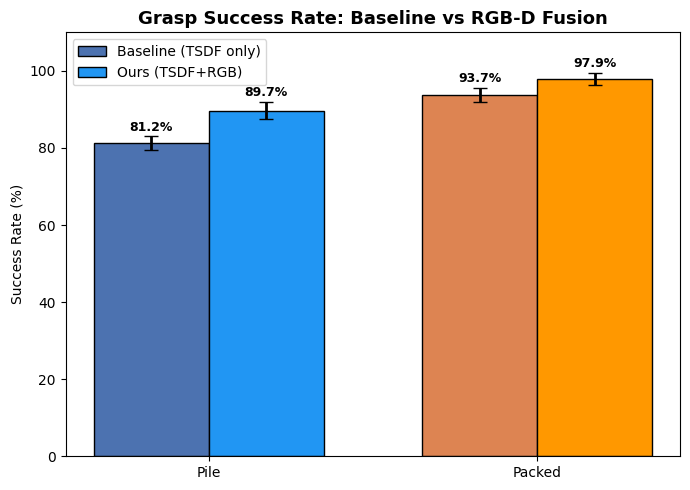

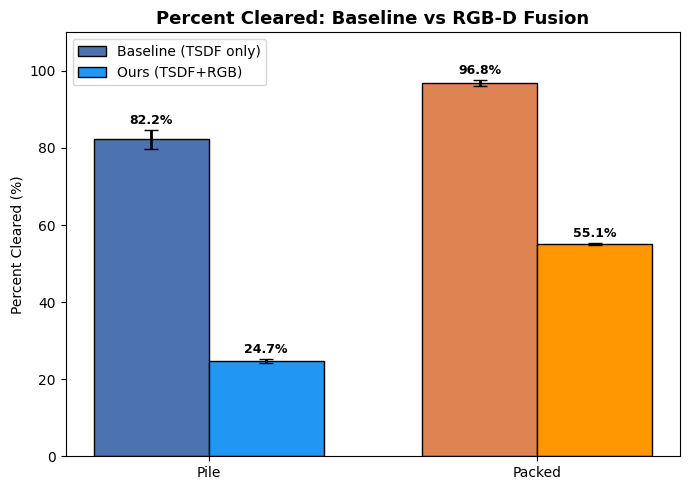

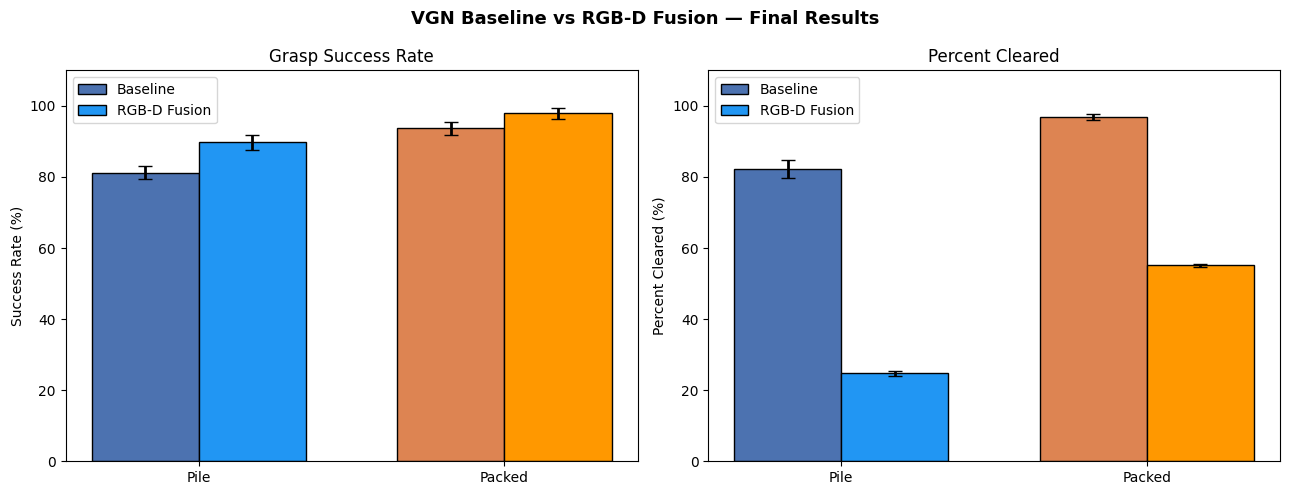

✅ All 3 graphs saved!


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data
scenes = ["Pile", "Packed"]
x = np.arange(2)
w = 0.35

base_sr  = [81.2, 93.7];  base_sr_s  = [1.8, 1.8]
base_pc  = [82.2, 96.8];  base_pc_s  = [2.5, 0.8]
rgbd_sr  = [89.7, 97.9];  rgbd_sr_s  = [2.2, 1.5]
rgbd_pc  = [24.7, 55.1];  rgbd_pc_s  = [0.6, 0.3]

colors_base = ["#4C72B0", "#DD8452"]
colors_rgbd = ["#2196F3", "#FF9800"]

# ── Graph 1: Success Rate comparison ─────────────────────────────
fig1, ax1 = plt.subplots(figsize=(7, 5))
b1 = ax1.bar(x-w/2, base_sr, w, yerr=base_sr_s, capsize=5,
             label="Baseline (TSDF only)", color=colors_base, edgecolor="black", error_kw={"linewidth":2})
b2 = ax1.bar(x+w/2, rgbd_sr, w, yerr=rgbd_sr_s, capsize=5,
             label="Ours (TSDF+RGB)", color=colors_rgbd, edgecolor="black", error_kw={"linewidth":2})
ax1.set_title("Grasp Success Rate: Baseline vs RGB-D Fusion", fontweight="bold", fontsize=13)
ax1.set_ylabel("Success Rate (%)")
ax1.set_xticks(x); ax1.set_xticklabels(scenes)
ax1.set_ylim(0, 110); ax1.legend()
for bar, v, s in zip(b1, base_sr, base_sr_s):
    ax1.text(bar.get_x()+bar.get_width()/2, v+s+1.5, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
for bar, v, s in zip(b2, rgbd_sr, rgbd_sr_s):
    ax1.text(bar.get_x()+bar.get_width()/2, v+s+1.5, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("data/experiments/final_success_rate.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Graph 2: Percent Cleared comparison ──────────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 5))
b3 = ax2.bar(x-w/2, base_pc, w, yerr=base_pc_s, capsize=5,
             label="Baseline (TSDF only)", color=colors_base, edgecolor="black", error_kw={"linewidth":2})
b4 = ax2.bar(x+w/2, rgbd_pc, w, yerr=rgbd_pc_s, capsize=5,
             label="Ours (TSDF+RGB)", color=colors_rgbd, edgecolor="black", error_kw={"linewidth":2})
ax2.set_title("Percent Cleared: Baseline vs RGB-D Fusion", fontweight="bold", fontsize=13)
ax2.set_ylabel("Percent Cleared (%)")
ax2.set_xticks(x); ax2.set_xticklabels(scenes)
ax2.set_ylim(0, 110); ax2.legend()
for bar, v, s in zip(b3, base_pc, base_pc_s):
    ax2.text(bar.get_x()+bar.get_width()/2, v+s+1.5, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
for bar, v, s in zip(b4, rgbd_pc, rgbd_pc_s):
    ax2.text(bar.get_x()+bar.get_width()/2, v+s+1.5, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("data/experiments/final_pct_cleared.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Graph 3: 4-panel summary ──────────────────────────────────────
fig3, axes = plt.subplots(1, 2, figsize=(13, 5))
fig3.suptitle("VGN Baseline vs RGB-D Fusion — Final Results", fontweight="bold", fontsize=13)

axes[0].bar(x-w/2, base_sr, w, yerr=base_sr_s, capsize=5,
            label="Baseline", color=colors_base, edgecolor="black", error_kw={"linewidth":2})
axes[0].bar(x+w/2, rgbd_sr, w, yerr=rgbd_sr_s, capsize=5,
            label="RGB-D Fusion", color=colors_rgbd, edgecolor="black", error_kw={"linewidth":2})
axes[0].set_title("Grasp Success Rate"); axes[0].set_ylabel("Success Rate (%)")
axes[0].set_xticks(x); axes[0].set_xticklabels(scenes)
axes[0].set_ylim(0, 110); axes[0].legend()

axes[1].bar(x-w/2, base_pc, w, yerr=base_pc_s, capsize=5,
            label="Baseline", color=colors_base, edgecolor="black", error_kw={"linewidth":2})
axes[1].bar(x+w/2, rgbd_pc, w, yerr=rgbd_pc_s, capsize=5,
            label="RGB-D Fusion", color=colors_rgbd, edgecolor="black", error_kw={"linewidth":2})
axes[1].set_title("Percent Cleared"); axes[1].set_ylabel("Percent Cleared (%)")
axes[1].set_xticks(x); axes[1].set_xticklabels(scenes)
axes[1].set_ylim(0, 110); axes[1].legend()

plt.tight_layout()
plt.savefig("data/experiments/final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ All 3 graphs saved!")